# ModelProject 1.3

1.1 The problem in nested budget shares

In [15]:
from types import SimpleNamespace

import numpy as np

from scipy import optimize

class ConsumerClass:
    """ a consumer with nested CES preferences over three goods

    Good 1 is food. Goods 2 and 3 are bus trips and train trips, and they sit
    together in a nest.

    The problem is written in *nested* budget shares, in the same two steps as
    the nests themselves:

        s1 = the share of income spent on food
        w  = the share of the remaining (travel) budget spent on the bus

    so that s2 = (1-s1)*w and s3 = (1-s1)*(1-w). Any (s1,w) in the unit square
    is a possible choice, and every possible choice is in the unit square, so
    the constraint set is exactly the box that L-BFGS-B takes as `bounds`.

    """

    def __init__(self,par=None):

        # a. setup
        self.setup()

        # b. update parameters
        if not par is None:
            for k,v in par.items():
                self.par.__dict__[k] = v

    def setup(self):
        """ set the baseline parameters """

        par = self.par = SimpleNamespace()
        sol = self.sol = SimpleNamespace()

        # a. preference weights
        par.alpha = 0.60 # weight on food
        par.beta = 0.50 # weight on the bus

        # b. substitution
        par.sigma_A = 0.80 # between food and travel (upper nest)
        par.sigma_B = 0.40 # between bus and train (lower nest)

        # c. prices and income
        par.p1 = 1.0 # price of food
        par.p2 = 1.0 # price of a bus trip
        par.p3 = 1.5 # price of a train trip
        par.I = 10.0 # income

        # d. numerical settings
        par.s_min = 1e-12 # smallest quantity allowed in .ces(), see the note there

    def __str__(self):
        """ print the parameters """

        par = self.par

        lines = ['ConsumerClass']
        lines.append(f'  alpha = {par.alpha:.4f}, beta = {par.beta:.4f}')
        lines.append(f'  sigma_A = {par.sigma_A:.4f}, sigma_B = {par.sigma_B:.4f}')
        lines.append(f'  p1 = {par.p1:.4f}, p2 = {par.p2:.4f}, p3 = {par.p3:.4f}')
        lines.append(f'  I = {par.I:.4f}')

        return '\n'.join(lines)

    ###################
    # 1. the CES nest #
    ###################

    def ces(self,z1,z2,w,sigma):
        """ the CES aggregate of two inputs

        Computes (w*z1**rho + (1-w)*z2**rho)**(1/rho) with rho = 1-1/sigma.

        The inputs are floored at par.s_min, because z**rho is not defined for
        z = 0 when rho < 0, and the corners of the unit square do give zeros.

        Note on the size of par.s_min. It must be *far* below the step that
        L-BFGS-B uses to estimate the gradient, which is `eps` and about 1e-8 by
        default. Otherwise both z and z+eps get floored to the same number near a
        bound, utility comes out exactly equal in the two points, the estimated
        gradient is zero, and the solver stops on the bound and stays there. With
        s_min = 1e-8 that really happens: the answers in section 4 for high tax
        rates come out as zero revenue. 1e-12 is small enough to be invisible and
        large enough to keep z**rho from overflowing.

        Args:

            z1 (float or ndarray): first input
            z2 (float or ndarray): second input
            w (float): weight on the first input
            sigma (float): substitution parameter, must not be 1

        Returns:

            (float or ndarray): the CES aggregate

        """

        par = self.par

        assert not np.isclose(sigma,1.0), 'sigma = 1 gives rho = 0 and a division by zero'

        z1 = np.maximum(z1,par.s_min)
        z2 = np.maximum(z2,par.s_min)

        rho = 1-1/sigma

        return (w*z1**rho + (1-w)*z2**rho)**(1/rho)

    def utility(self,x1,x2,x3):
        """ nested CES utility of a bundle of quantities

        Two steps: first combine goods 2 and 3 into the travel composite, then
        combine good 1 and the composite into utility. Use .ces() for both.

        Args:

            x1 (float or ndarray): quantity of good 1
            x2 (float or ndarray): quantity of good 2
            x3 (float or ndarray): quantity of good 3

        Returns:

            (float or ndarray): utility

        """

        par = self.par

        xB = self.ces(x2, x3, par.beta, par.sigma_B)
        
        u = self.ces(x1, xB, par.alpha, par.sigma_A)

        return u

    ###############################
    # 2. the nested budget shares #
    ###############################

    def shares(self,s1,w):
        """ the three budget shares implied by the nested shares

        Args:

            s1 (float or ndarray): share of income spent on food
            w (float or ndarray): share of the travel budget spent on the bus

        Returns:

            (tuple): the three budget shares, which always sum to one

        """

        return s1,(1-s1)*w,(1-s1)*(1-w)

    def quantities(self,s1,w):
        """ the quantities implied by the nested shares

        Args:

            s1 (float or ndarray): share of income spent on food
            w (float or ndarray): share of the travel budget spent on the bus

        Returns:

            (tuple): the three quantities

        """

        par = self.par

        s1,s2,s3 = self.shares(s1,w)

        return s1*par.I/par.p1, s2*par.I/par.p2, s3*par.I/par.p3

    def value_of_choice(self,s1,w):
        """ utility of the bundle implied by the nested shares

        Args:

            s1 (float or ndarray): share of income spent on food
            w (float or ndarray): share of the travel budget spent on the bus

        Returns:

            (float or ndarray): utility

        """

        x1, x2, x3 = self.quantities(s1, w)
        u = self.utility(x1, x2, x3)

        return u

    def objective(self,s):
        """ minus utility, for a minimizer

        Nothing else is needed: the bounds are the whole constraint.

        Args:

            s (ndarray): array of length 2 with (s1,w)

        Returns:

            (float): minus utility

        """

        return -self.value_of_choice(s[0],s[1])

    #################
    # 3. solving it #
    #################

    def solve_grid(self,N=200,do_print=True):
        """ solve by a 2-dimensional grid search over the nested shares

        Every point of the unit square is a possible choice, so there is nothing
        to mask out here -- a plain np.argmax will do.

        Args:

            N (int): number of grid points for each variable
            do_print (bool): print the solution

        Returns:

            (SimpleNamespace): the grids, the utility values and the best point

        """

        par = self.par
        opt = SimpleNamespace()

        # a. the two grids
        s1_vec = np.linspace(0, 1, N)
        w_vec = np.linspace(0, 1, N)

        opt.s1_grid, opt.w_grid = np.meshgrid(
            s1_vec, w_vec, indexing='ij'
         )

        # b. utility in every grid point
        opt.u_grid = self.value_of_choice(
            opt.s1_grid,
            opt.w_grid
        )

        # c. the best point
        idx = np.unravel_index(
           np.argmax(opt.u_grid),
           opt.u_grid.shape
        )

        opt.s1 = opt.s1_grid[idx]
        opt.w = opt.w_grid[idx]

        opt.s2 = (1 - opt.s1) * opt.w
        opt.s3 = (1 - opt.s1) * (1 - opt.w)

        opt.u = opt.u_grid[idx]

        # d. results
        #opt.s1, opt.w, opt.s2, opt.s3, opt.u
        #opt.s1_grid, opt.w_grid, opt.u_grid (needed for the figures)

        return opt

    def solve(self,s0=None,do_print=True,**kwargs):
        """ solve with L-BFGS-B

        The bounds are ((0,1),(0,1)) -- the whole constraint set.

        Args:

            s0 (ndarray): starting guess for (s1,w)
            do_print (bool): print the solution
            kwargs: passed on to optimize.minimize, e.g. options={'ftol':1e-10}

        Returns:

            (SimpleNamespace): the solution and the convergence path

        """

        par = self.par
        opt = SimpleNamespace()

        # a. starting guess
        if s0 is None: s0 = np.array([0.5,0.5])
        s0 = np.asarray(s0,dtype=float)

        # b. record the path with a callback
        path = [s0.copy()]

        # c. minimize
        res = optimize.minimize(
           self.objective,
           s0,
           method='L-BFGS-B',
           bounds=((0,1),(0,1)),
           callback=lambda sk: path.append(sk.copy()),
           **kwargs
        )

        # d. results
        opt.s1 = res.x[0]
        opt.w = res.x[1]
        opt.s2 = (1 - opt.s1) * opt.w
        opt.s3 = (1 - opt.s1) * (1 - opt.w)
        opt.u = -res.fun
        opt.path = path
        opt.res = res

        return opt


Test Question 1

In [16]:
model = ConsumerClass()

grid_sol = model.solve_grid(N=500)

print("Grid solution:")
print("s1 =", grid_sol.s1)
print("w  =", grid_sol.w)
print("s2 =", grid_sol.s2)
print("s3 =", grid_sol.s3)
print("u  =", grid_sol.u)

Grid solution:
s1 = 0.5350701402805611
w  = 0.438877755511022
s2 = 0.20404737330372166
s3 = 0.26088248641571726
u  = 3.40167436585882


Compare with L-BFGS-B

In [17]:
sol = model.solve()

print("\nL-BFGS-B solution:")
print("s1 =", sol.s1)
print("w  =", sol.w)
print("s2 =", sol.s2)
print("s3 =", sol.s3)
print("u  =", sol.u)


L-BFGS-B solution:
s1 = 0.5356233806953101
w  = 0.43947902810370126
s2 = 0.20408378532610758
s3 = 0.26029283397858227
u  = 3.401679875985606


In [18]:
sol.s1 + sol.s2 + sol.s3

np.float64(1.0)

### 1.2 Calibration

In [19]:
model_sub = ConsumerClass(par={'sigma_B': 3.0})

### 1.3 How do you know your answer is right?

There is no formula for the solution of this model, so you cannot look the answer up. Two cheap checks: 

1. is the answer possible? All three shares should be strictly between 0 and 1 aand sum to one, and all three quantities should be positive

Check that the solution is possible

In [21]:
print("Budget shares:")
print("s1 =", sol.s1)
print("s2 =", sol.s2)
print("s3 =", sol.s3)

print("\nSum of shares:")
print(sol.s1 + sol.s2 + sol.s3)

print("\nQuantities:")
x1, x2, x3 = model.quantities(sol.s1, sol.w)

print("x1 =", x1)
print("x2 =", x2)
print("x3 =", x3)

Budget shares:
s1 = 0.5356233806953101
s2 = 0.20408378532610758
s3 = 0.26029283397858227

Sum of shares:
1.0

Quantities:
x1 = 5.356233806953101
x2 = 2.040837853261076
x3 = 1.7352855598572152


In [22]:
0 < sol.s1 < 1
0 < sol.s2 < 1
0 < sol.s3 < 1

np.True_

In [23]:
sol.s1 + sol.s2 + sol.s3

np.float64(1.0)

In [24]:
x1 > 0
x2 > 0
x3 > 0

np.True_

In [25]:
print("All shares between 0 and 1:",
      0 < sol.s1 < 1 and
      0 < sol.s2 < 1 and
      0 < sol.s3 < 1)

print("Shares sum to 1:",
      np.isclose(sol.s1 + sol.s2 + sol.s3, 1))

print("All quantities positive:",
      x1 > 0 and x2 > 0 and x3 > 0)

All shares between 0 and 1: True
Shares sum to 1: True
All quantities positive: True


2. Do two different methods agree? In section 2 you solve the same problem twice.

In [26]:
grid_sol = model.solve_grid(N=1000)
sol = model.solve()

# Grid search:
print("Grid search:")
print("s1 =", grid_sol.s1)
print("w  =", grid_sol.w)
print("u  =", grid_sol.u)

# L-BFGS-B optimization:
print("\nL-BFGS-B:")
print("s1 =", sol.s1)
print("w  =", sol.w)
print("u  =", sol.u)

Grid search:
s1 = 0.5355355355355356
w  = 0.4394394394394394
u  = 3.4016797975402664

L-BFGS-B:
s1 = 0.5356233806953101
w  = 0.43947902810370126
u  = 3.401679875985606


The grid search only consider a finite number of points, so its result will not necessary be identical to L-BFGS-B. But with a sufficient fine grid, the results should be almost identical. 

Calculate the difference:

In [27]:
print("Difference in s1:",
      abs(grid_sol.s1 - sol.s1))

print("Difference in w:",
      abs(grid_sol.w - sol.w))

print("Difference in utility:",
      abs(grid_sol.u - sol.u))

Difference in s1: 8.784515977455776e-05
Difference in w: 3.958866426184704e-05
Difference in utility: 7.844533955747579e-08


The solution passes both checks. All three budget shares are strictly between 0 and 1 and sum to one, which satisfies the budget constraint. The corresponding quantities of food, bus trips, and train trips are all positive. The grid search and L-BFGS-B methods produce a very similar optimal shares and utility levels. Since two independent numerical methods arrive at approximately the same solution, this provides strong evidence that the numerical solution is correct.

## Question 2 - Solving the model numerically

we solve eq. 4 twice, in two very different ways.

### 2.1 A two-dimensional grid search

1. Make a grid of N values of s1 and N values of w, both from 0 to 1, compute utility in every combination, and keep the best point. Implement it as solve_grid
(). Report both (s1, w) and the three budget shares it implies.
Hint: np.meshgrid(s1_vec,w_vec,indexing=’ij’) builds the grid, and np.argmax
together with np.unravel_index finds the best point. Note that there is nothing
to mask out and no np.nan anywhere: every point of the square is a possible
choice.

Ask how do I use the hint.

In [29]:
model = ConsumerClass()

for N in [50, 100, 500, 1000]:
    sol_grid = model.solve_grid(N=N)

    print(f"N = {N}")
    print(f"s1 = {sol_grid.s1:.6f}")
    print(f"w  = {sol_grid.w:.6f}")
    print(f"s2 = {sol_grid.s2:.6f}")
    print(f"s3 = {sol_grid.s3:.6f}")
    print(f"u  = {sol_grid.u:.6f}")
    print()

N = 50
s1 = 0.530612
w  = 0.448980
s2 = 0.210746
s3 = 0.258642
u  = 3.400748

N = 100
s1 = 0.535354
w  = 0.444444
s2 = 0.206510
s3 = 0.258137
u  = 3.401482

N = 500
s1 = 0.535070
w  = 0.438878
s2 = 0.204047
s3 = 0.260882
u  = 3.401674

N = 1000
s1 = 0.535536
w  = 0.439439
s2 = 0.204104
s3 = 0.260360
u  = 3.401680



##### The grid results does not necessarily improve smoothly. The optimum can jump from one grid point to another as N increase.

2. Plot utility over the nested shares in 3D (ax = fig.add_subplot(1,2,1,projection
=’3d’) and ax.plot_surface) and as a contour plot (ax.contourf), with the
solution marked.

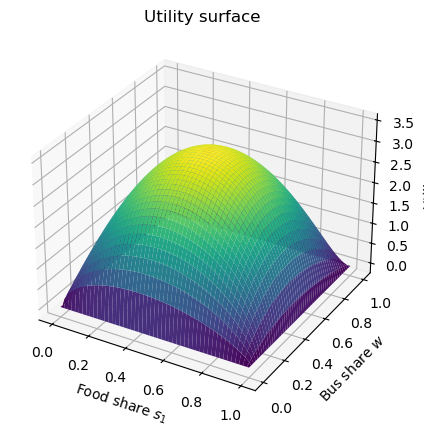

In [30]:
import matplotlib.pyplot as plt

model = ConsumerClass()

grid_sol = model.solve_grid(N=100)

fig = plt.figure(figsize=(12, 5))

ax = fig.add_subplot(1, 2, 1, projection='3d')

ax.plot_surface(
    grid_sol.s1_grid,
    grid_sol.w_grid,
    grid_sol.u_grid,
    cmap='viridis'
)

ax.scatter(
    grid_sol.s1,
    grid_sol.w,
    grid_sol.u,
    color='red',
    s=50
)

ax.set_xlabel('Food share $s_1$')
ax.set_ylabel('Bus share $w$')
ax.set_zlabel('Utility')
ax.set_title('Utility surface')

plt.show()

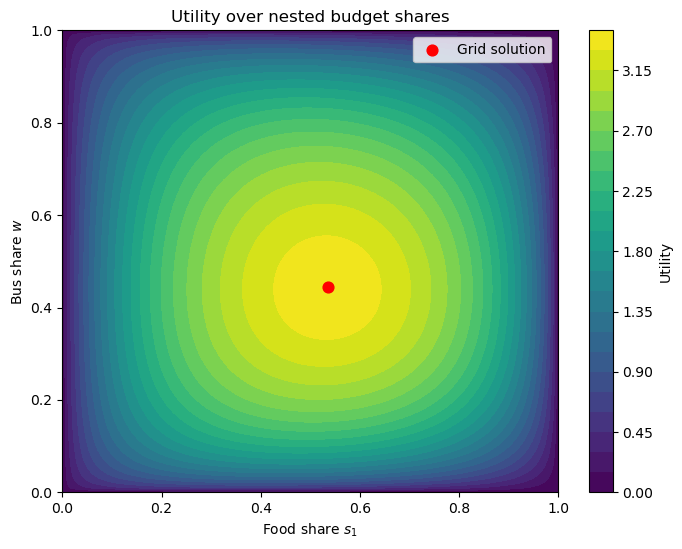

In [32]:
fig, ax = plt.subplots(figsize=(8, 6))

contour = ax.contourf(
    grid_sol.s1_grid,
    grid_sol.w_grid,
    grid_sol.u_grid,
    levels=30
)

ax.scatter(
    grid_sol.s1,
    grid_sol.w,
    color='red',
    s=60,
    label='Grid solution'
)

ax.set_xlabel('Food share $s_1$')
ax.set_ylabel('Bus share $w$')
ax.set_title('Utility over nested budget shares')

plt.colorbar(contour, ax=ax, label='Utility')
ax.legend()

plt.show()

3. Try N = 50, 100, 500 and 1000. How much does the answer move when you
add points, and how many evaluations of u does it cost? Does it improve
smoothly?

4. Compare the two calibrations. Where is the surface steep, and where is it flat?
Which of the two would you expect to be harder for an optimizer?

Complements

In [33]:
model_comp = ConsumerClass()

In [36]:
sigma_B = 0.40

Substitutes

In [35]:
model_sub = ConsumerClass(
    par={'sigma_B': 3.0}
)

sigma_B = 0.40 for complements and sigma_B = 3.00 for substitutes.

In [37]:
comp_sol = model_comp.solve_grid(N=500)
sub_sol = model_sub.solve_grid(N=500)

print("COMPLEMENTS")
print("s1 =", comp_sol.s1)
print("w  =", comp_sol.w)
print("s2 =", comp_sol.s2)
print("s3 =", comp_sol.s3)
print("u  =", comp_sol.u)

print("\nSUBSTITUTES")
print("s1 =", sub_sol.s1)
print("w  =", sub_sol.w)
print("s2 =", sub_sol.s2)
print("s3 =", sub_sol.s3)
print("u  =", sub_sol.u)

COMPLEMENTS
s1 = 0.5350701402805611
w  = 0.438877755511022
s2 = 0.20404737330372166
s3 = 0.26088248641571726
u  = 3.40167436585882

SUBSTITUTES
s1 = 0.5390781563126252
w  = 0.691382765531062
s2 = 0.31867341898225304
s3 = 0.14224842470512172
u  = 3.4850971386959047


Interpretation

For the complements calibration, bus and train are difficult to substitute for each other during to sigma_B = 0.4 < 1. So, the consumer wants a combination of bus and train.

For the substitutes calibration. sigma_B = 3 > 1. Bus and train are easier to substitute, so the consumer has a greater incentive to shift over to the cheaper travel option. 

### 2.2 L-BFGS-B

In [38]:
model = ConsumerClass()

sol = model.solve()

print("L-BFGS-B solution")
print("s1 =", sol.s1)
print("w  =", sol.w)
print("s2 =", sol.s2)
print("s3 =", sol.s3)
print("u  =", sol.u)

L-BFGS-B solution
s1 = 0.5356233806953101
w  = 0.43947902810370126
s2 = 0.20408378532610758
s3 = 0.26029283397858227
u  = 3.401679875985606


In [39]:
method='L-BFGS-B'

In [40]:
bounds=((0,1),(0,1))

Compare grid search and L-BFGS-B

In [41]:
grid_sol = model.solve_grid(N=1000)
sol = model.solve()

print("Grid search")
print("s1 =", grid_sol.s1)
print("w  =", grid_sol.w)
print("u  =", grid_sol.u)

print("\nL-BFGS-B")
print("s1 =", sol.s1)
print("w  =", sol.w)
print("u  =", sol.u)

print("\nDifferences")
print("s1 difference =", abs(grid_sol.s1 - sol.s1))
print("w difference  =", abs(grid_sol.w - sol.w))
print("u difference  =", abs(grid_sol.u - sol.u))

Grid search
s1 = 0.5355355355355356
w  = 0.4394394394394394
u  = 3.4016797975402664

L-BFGS-B
s1 = 0.5356233806953101
w  = 0.43947902810370126
u  = 3.401679875985606

Differences
s1 difference = 8.784515977455776e-05
w difference  = 3.958866426184704e-05
u difference  = 7.844533955747579e-08


We can see that the two solution are very close, although the grid solution may not be exactly identical during to it only points what are on the grid. The L-BFGS-B solution should be more preise and better than a grid.

2. Record the convergence path with the callback argument of optimize.minimize
, and draw it on top of the contour plot from section 2.1. Then plot how far each
iteration is from the point the solver ends at, against the iteration number, on a
log scale. Where does the method make fast progress, and where is it slow?

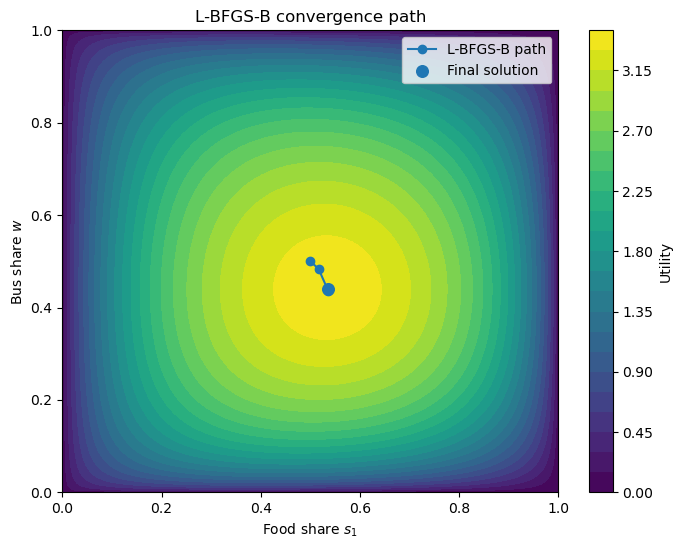

In [43]:
grid_sol = model.solve_grid(N=200)
sol = model.solve()

fig, ax = plt.subplots(figsize=(8, 6))

contour = ax.contourf(
    grid_sol.s1_grid,
    grid_sol.w_grid,
    grid_sol.u_grid,
    levels=30
)

path = np.array(sol.path)

ax.plot(
    path[:, 0],
    path[:, 1],
    marker='o',
    label='L-BFGS-B path'
)

ax.scatter(
    sol.s1,
    sol.w,
    s=70,
    label='Final solution'
)

ax.set_xlabel('Food share $s_1$')
ax.set_ylabel('Bus share $w$')
ax.set_title('L-BFGS-B convergence path')

plt.colorbar(contour, ax=ax, label='Utility')
ax.legend()

plt.show()

Distance from final solution on a log scale

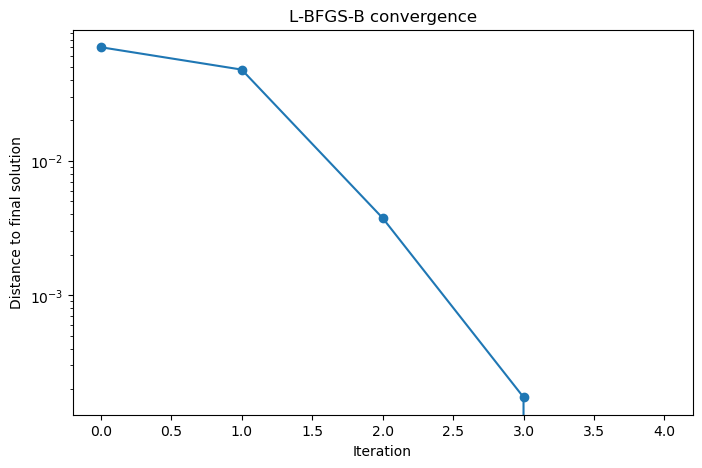

In [44]:
path = np.array(sol.path)

distance = np.sqrt(
    (path[:, 0] - sol.s1)**2 +
    (path[:, 1] - sol.w)**2
)

plt.figure(figsize=(8, 5))

plt.plot(
    range(len(distance)),
    distance,
    marker='o'
)

plt.yscale('log')

plt.xlabel('Iteration')
plt.ylabel('Distance to final solution')
plt.title('L-BFGS-B convergence')

plt.show()

Interpretation

The algorithm is converging, and the distance is approximately falling toward zero.

The decline stating out flat which means the optimizer is making a slower progress, and then the decline turn out to be more steep, which means the optimizer is making a fast progress toward the solution.

3. Solve from at least six different starting points, including the middle (1/2, 1/2)
and all four corners of the square. Do you always get the same answer? Does
the number of iterations change?

In [45]:
starting_points = [
    [0.5, 0.5],
    [0.0, 0.0],
    [0.0, 1.0],
    [1.0, 0.0],
    [1.0, 1.0],
    [0.25, 0.75]
]

for s0 in starting_points:

    sol = model.solve(s0=s0)

    print(
        f"s0={s0} -> "
        f"s1={sol.s1:.6f}, "
        f"w={sol.w:.6f}, "
        f"u={sol.u:.6f}, "
        f"iterations={len(sol.path)-1}, "
        f"success={sol.res.success}"
    )

s0=[0.5, 0.5] -> s1=0.535623, w=0.439479, u=3.401680, iterations=4, success=True
s0=[0.0, 0.0] -> s1=0.535624, w=0.439478, u=3.401680, iterations=7, success=True
s0=[0.0, 1.0] -> s1=0.535624, w=0.439478, u=3.401680, iterations=9, success=True
s0=[1.0, 0.0] -> s1=0.999991, w=0.000000, u=0.000000, iterations=1, success=True
s0=[1.0, 1.0] -> s1=0.999991, w=1.000000, u=0.000000, iterations=1, success=True
s0=[0.25, 0.75] -> s1=0.535624, w=0.439479, u=3.401680, iterations=6, success=True


This shows whether L-BFGS-B finds the same optimum regardless of where it starts.

4. Vary the settings below -- they all go in options={...} -- and report the two
shares, the utility reached and the number of function evaluations for each of
them in one table:
(a) ftol (stop when the objective stops changing): 10^(−4)
, 10^(−8)
, 10^(−12), 10^(−16)
(b) gtol (stop when the gradient is small): 10^(−2)
, 10^(−5)
, 10^(−8)
, 10^(−12)

Compare ftol

In [46]:
ftol_values = [1e-4, 1e-8, 1e-12, 1e-16]

for ftol in ftol_values:

    sol = model.solve(
        options={'ftol': ftol}
    )

    print(
        f"ftol={ftol:.0e}: "
        f"s1={sol.s1:.8f}, "
        f"w={sol.w:.8f}, "
        f"u={sol.u:.8f}, "
        f"function evaluations={sol.res.nfev}"
    )

ftol=1e-04: s1=0.53560667, w=0.43965199, u=3.40167963, function evaluations=15
ftol=1e-08: s1=0.53562338, w=0.43947903, u=3.40167988, function evaluations=18
ftol=1e-12: s1=0.53562338, w=0.43947903, u=3.40167988, function evaluations=18
ftol=1e-16: s1=0.53562338, w=0.43947903, u=3.40167988, function evaluations=18


Compare gtol

In [47]:
gtol_values = [1e-2, 1e-5, 1e-8, 1e-12]

for gtol in gtol_values:

    sol = model.solve(
        options={'gtol': gtol}
    )

    print(
        f"gtol={gtol:.0e}: "
        f"s1={sol.s1:.8f}, "
        f"w={sol.w:.8f}, "
        f"u={sol.u:.8f}, "
        f"function evaluations={sol.res.nfev}"
    )

gtol=1e-02: s1=0.53560667, w=0.43965199, u=3.40167963, function evaluations=15
gtol=1e-05: s1=0.53562338, w=0.43947903, u=3.40167988, function evaluations=18
gtol=1e-08: s1=0.53562357, w=0.43947843, u=3.40167988, function evaluations=21
gtol=1e-12: s1=0.53562357, w=0.43947843, u=3.40167988, function evaluations=21


5. Which settings would you use? Note that you can rank them without knowing
the true answer: we are maximizing, so a higher utility is a better answer.
Why is a tighter tolerance not always a better answer?

#2.1 Grid search:

We solved the consumer's problem using a two-dimensional grid search over the nested budget share s_1 and w. We used grid with 50, 100, 500 and 1000 points for each variable. As the grid becomes finer, the solution will be more precise, during to more possible combinations of the two shares are evaluated. However the computational cost increases rapidly because the evaluations number is N^2

#2.2 L-BFGS-B

Afterwards we solved the same problem by using the L-BFGS-B optimization algorithm. The feasible set is [0,1]x[0,1], so the two nested shares can be used directly as the optimization variables. The L-BFGS-B solution is very close to the grid-search solution, which confirms the numerical result. 

#Convergence 

The convergence path shows how L-BFGS-B approximate toward the optimum from the initial value. The distance to the final solution generally decreases over the ITERATIONS. The optimizer makes the fastest progress when it is far from the optimum and slows down as it approaches the solution.

#Starting values

We tested several different starting values, including the center and all four corners of the feasible region. By Comparing the results shows whether the optimizer consistently finds the same solution. Differences in convergence speed can occur even when the final solution is the same. 

#Tolerances??? 
A stricter tolerance means the optimizer must search more precisely for the optimal solution, which can result in more function evaluations. However, using a very small tolerance is not always beneficial, since higher numerical accuracy requires more computational effort. Extremely strict tolerances may therefore increase computation time without significantly improving the final result.



## 3 Relative prices and demand